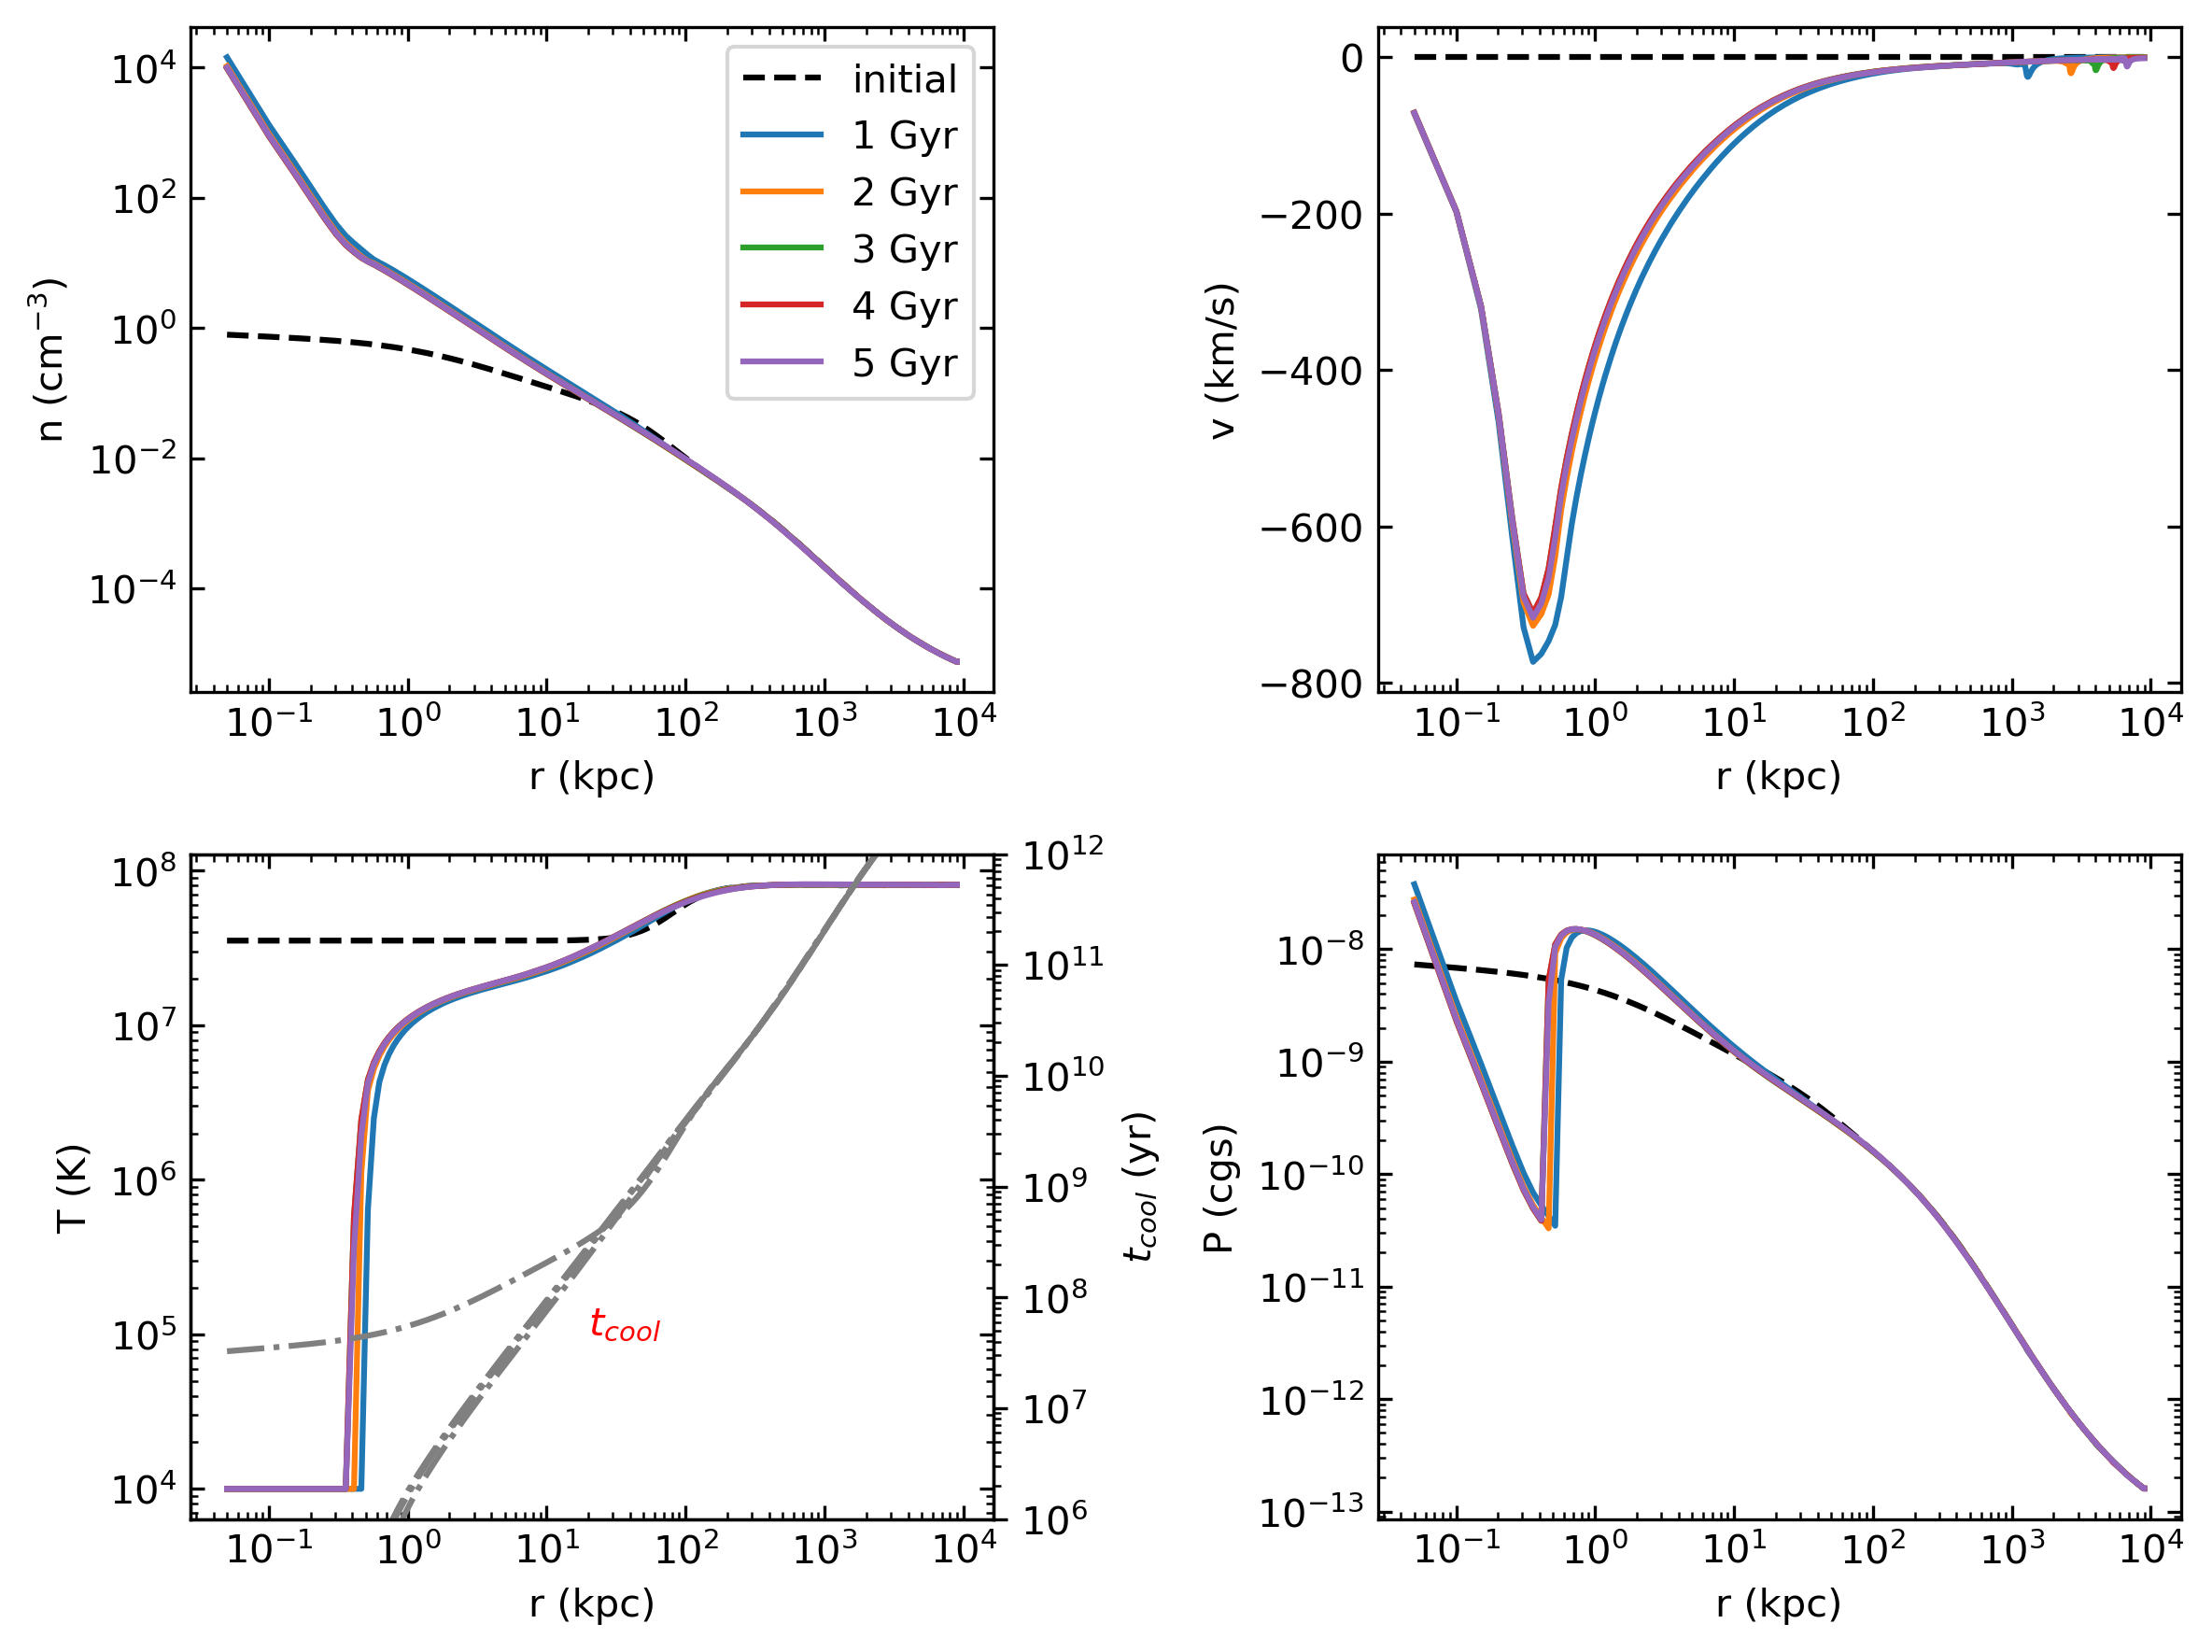

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import glob

files = sorted(glob.glob('clu00*'))
data = np.loadtxt('resinit.dat')

fig, ax = plt.subplots(2,2,figsize=(8,6),dpi=300)
axs = ax.flatten()
ax2_right = axs[2].twinx()

# initial data
xa = data[:,0]  # kpc
xb = data[:,1] 
rho = data[:,2] 
vel = data[:,3]
tep = data[:,4]
p = data[:,5]
tcool = data[:,6]
axs[0].plot(xa, rho, label=f'initial', c='k',ls='--')
axs[1].plot(xa, vel, label='Velocity', c='k',ls='--')
axs[2].plot(xa, tep, label='Temperature', c='k',ls='--')
ax2_right.plot(xa, tcool, label='Cooling time (yr)', c='gray',ls='-.') # 时间到底怎么画
axs[3].plot(xa, p, label='Pressure', c='k',ls='--')


for i in range(len(files)):
    Stand_simu = np.loadtxt(files[i]) 
    xa = Stand_simu[:,0]  # kpc
    xb = Stand_simu[:,1] 
    rho = Stand_simu[:,2] 
    vel = Stand_simu[:,3]
    tep = Stand_simu[:,4]
    p = Stand_simu[:,5]
    tcool = Stand_simu[:,6]

  
    axs[0].plot(xa, rho, label=f'{i+1} Gyr', )
    axs[1].plot(xa, vel, label='Velocity') 
    axs[2].plot(xa, tep, label='Temperature')
    axs[3].plot(xa, p, label='Pressure')
    ax2_right.plot(xa, tcool, label='Cooling time (yr)',ls='-.',c='gray') # 时间到底怎么画
    for j in range(0, 4):
        # axs[j].yaxis.set_minor_locator(MultipleLocator(0.5))
        axs[j].set_xlabel('r (kpc)')
        axs[0].set_ylabel(r'n $({\rm cm^{-3}})$')
        axs[1].set_ylabel("v (km/s)")
        axs[2].set_ylabel("T (K)")
        ax2_right.set_ylabel(r'$t_{cool}$ (yr)')
        axs[3].set_ylabel("P (cgs)")
        axs[j].set_xscale('log')
        axs[j].tick_params(right='on',top='on', which='major',direction='in')
        axs[j].tick_params(right='on',top='on', which='minor',direction='in')
    axs[0].set_yscale('log')
    axs[2].set_yscale('log')  
    ax2_right.set_yscale('log')  
    axs[3].set_yscale('log')
    
    ax2_right.set_ylim(10**6,10**12)
    
        
axs[0].legend()
axs[2].text(20, 10**5, r'$t_{cool}$', color='r')
    
# plt.suptitle('Iron abundance with only diffusion')
fig.tight_layout(rect=[0, 0, 1, 1.0])

plt.savefig('quantities.pdf', format='pdf',dpi=300,bbox_inches='tight')

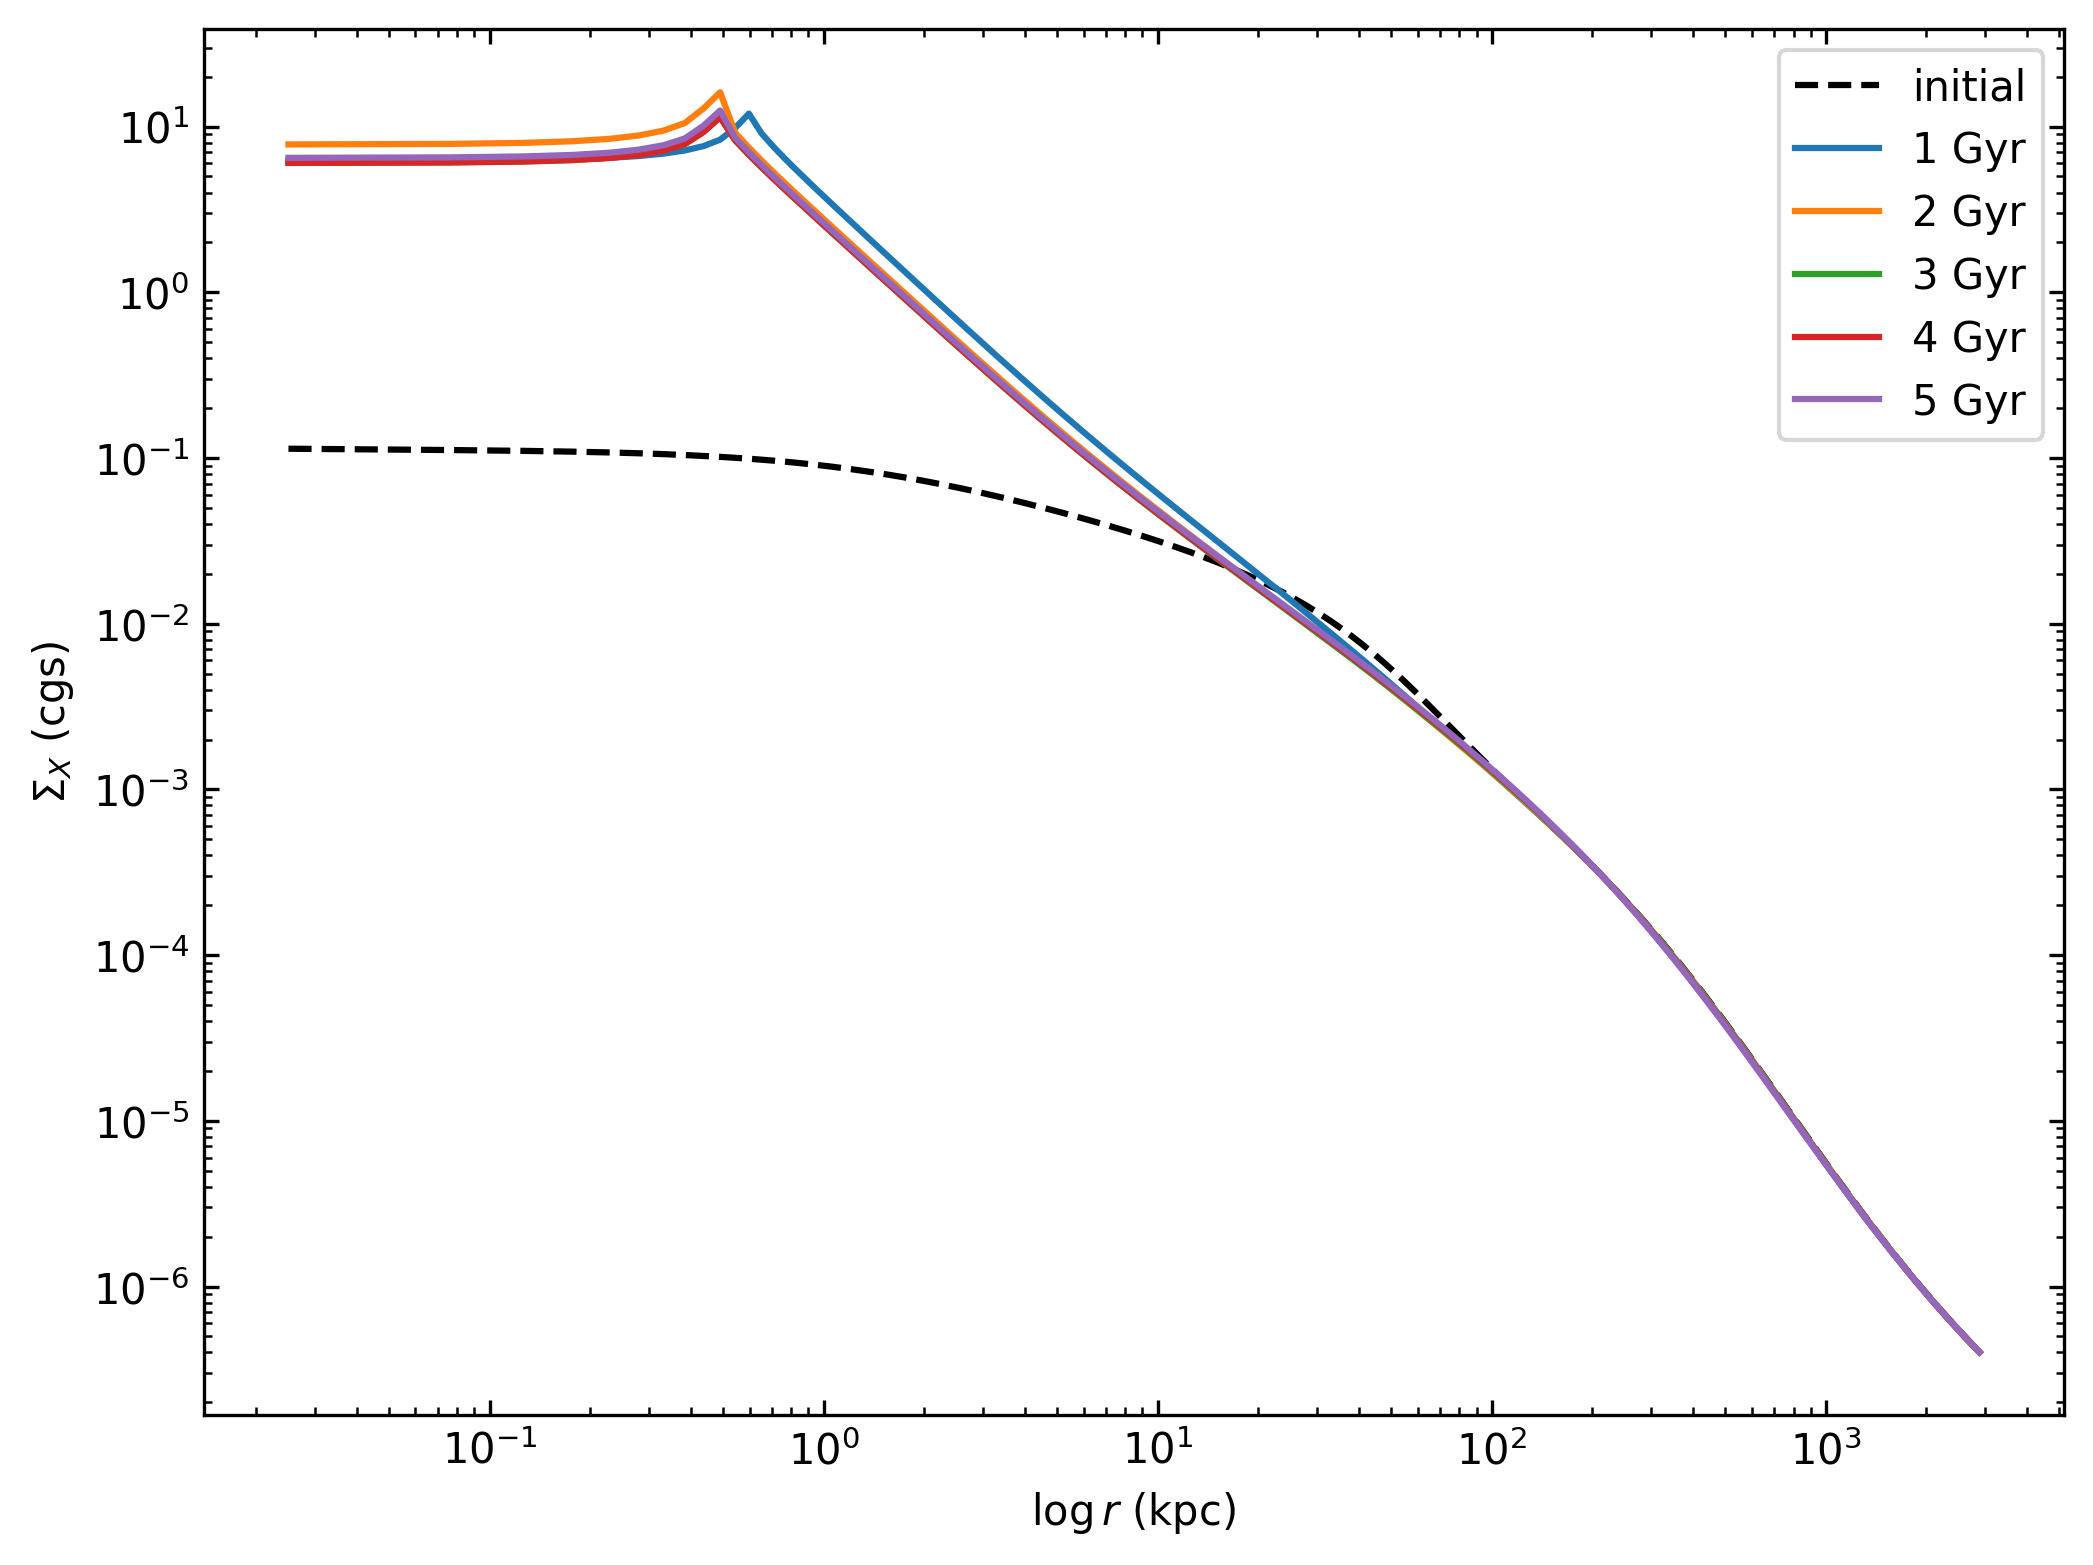

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import glob

files = sorted(glob.glob('bright*'))
initb = np.loadtxt('bri_init.dat')
xb = initb[:,0]  # kpc
bright = initb[:,1]

fig, ax = plt.subplots(figsize=(8,6),dpi=300)
plt.plot(initb[:,0], initb[:,1], label='initial', c='k',ls='--')
for i in range(len(files)):
    data = np.loadtxt(files[i]) 
    xb = data[:,0]  # kpc
    bright = data[:,1]
    entropy = data[:,2]
    t_dyn = data[:,3]
    t_cool = data[:,4]
    
    plt.plot(xb, bright, label=f'{i+1} Gyr')


plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\log r$ (kpc)')
plt.ylabel(r'$\Sigma_X$ (cgs)')
# plt.ylim(0,2.5)
# plt.xlim(-0.5,3.2)
plt.legend()
ax.tick_params(right='on',top='on', which='major',direction='in')
ax.tick_params(right='on',top='on', which='minor',direction='in')
# ax.xaxis.set_minor_locator(MultipleLocator(0.1))
# ax.yaxis.set_minor_locator(MultipleLocator(0.1))
plt.savefig('brightness_profile.pdf', format='pdf',dpi=300,bbox_inches='tight')

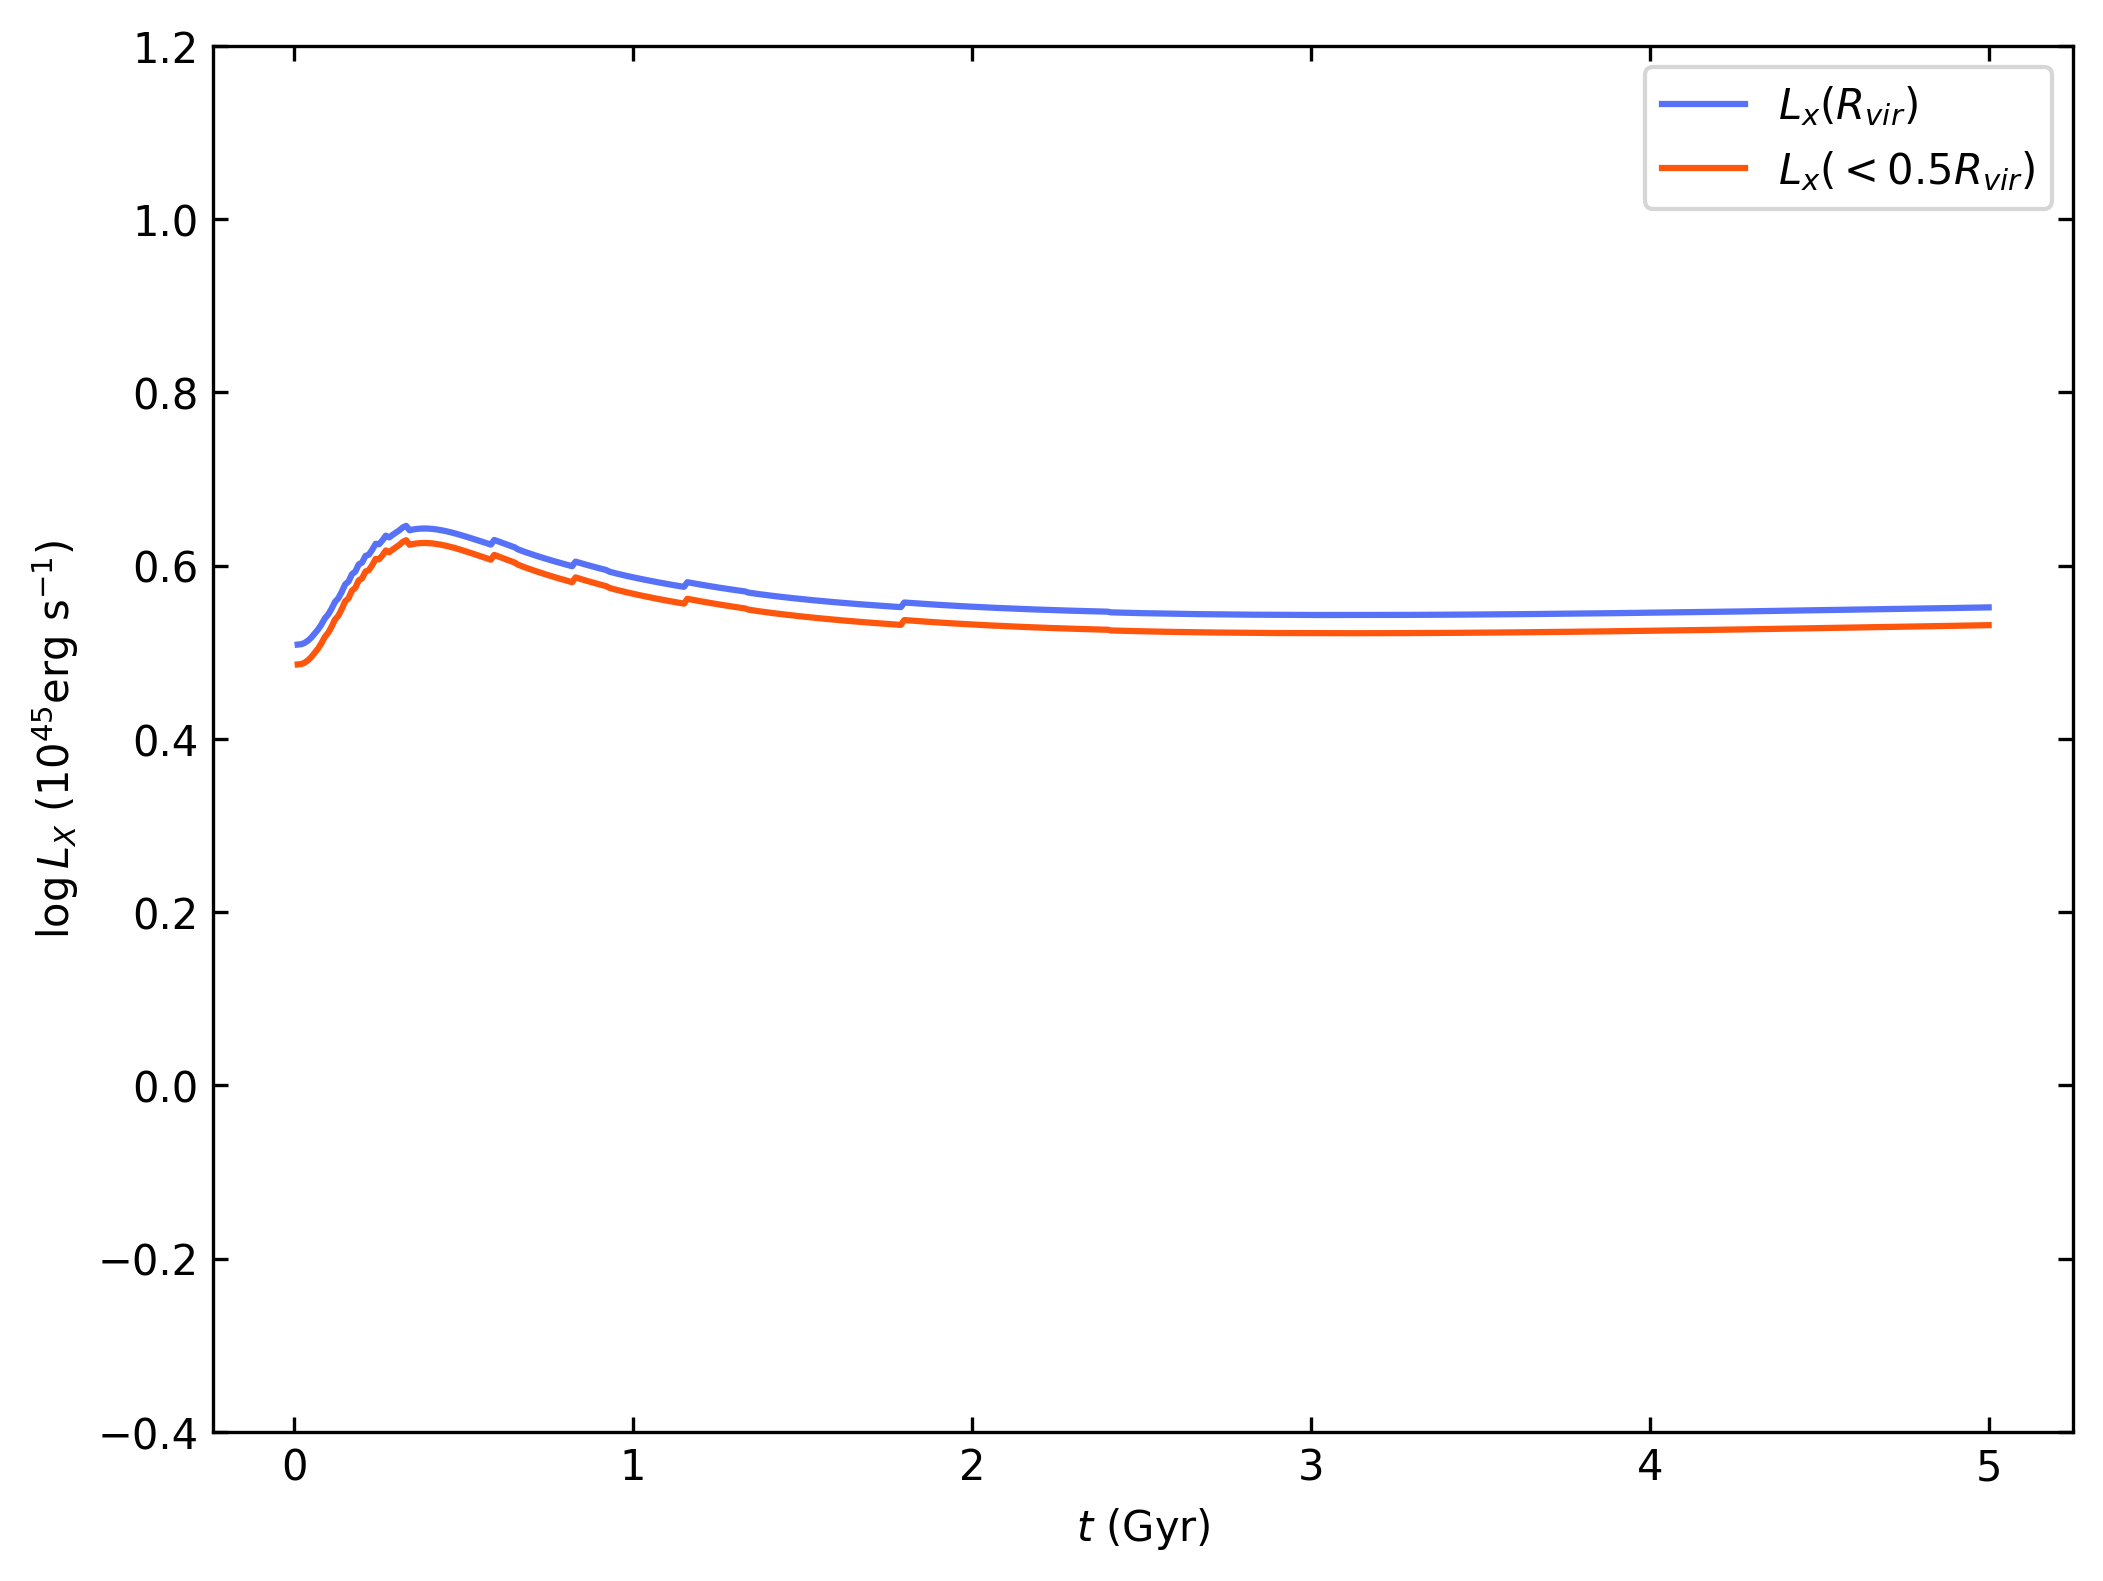

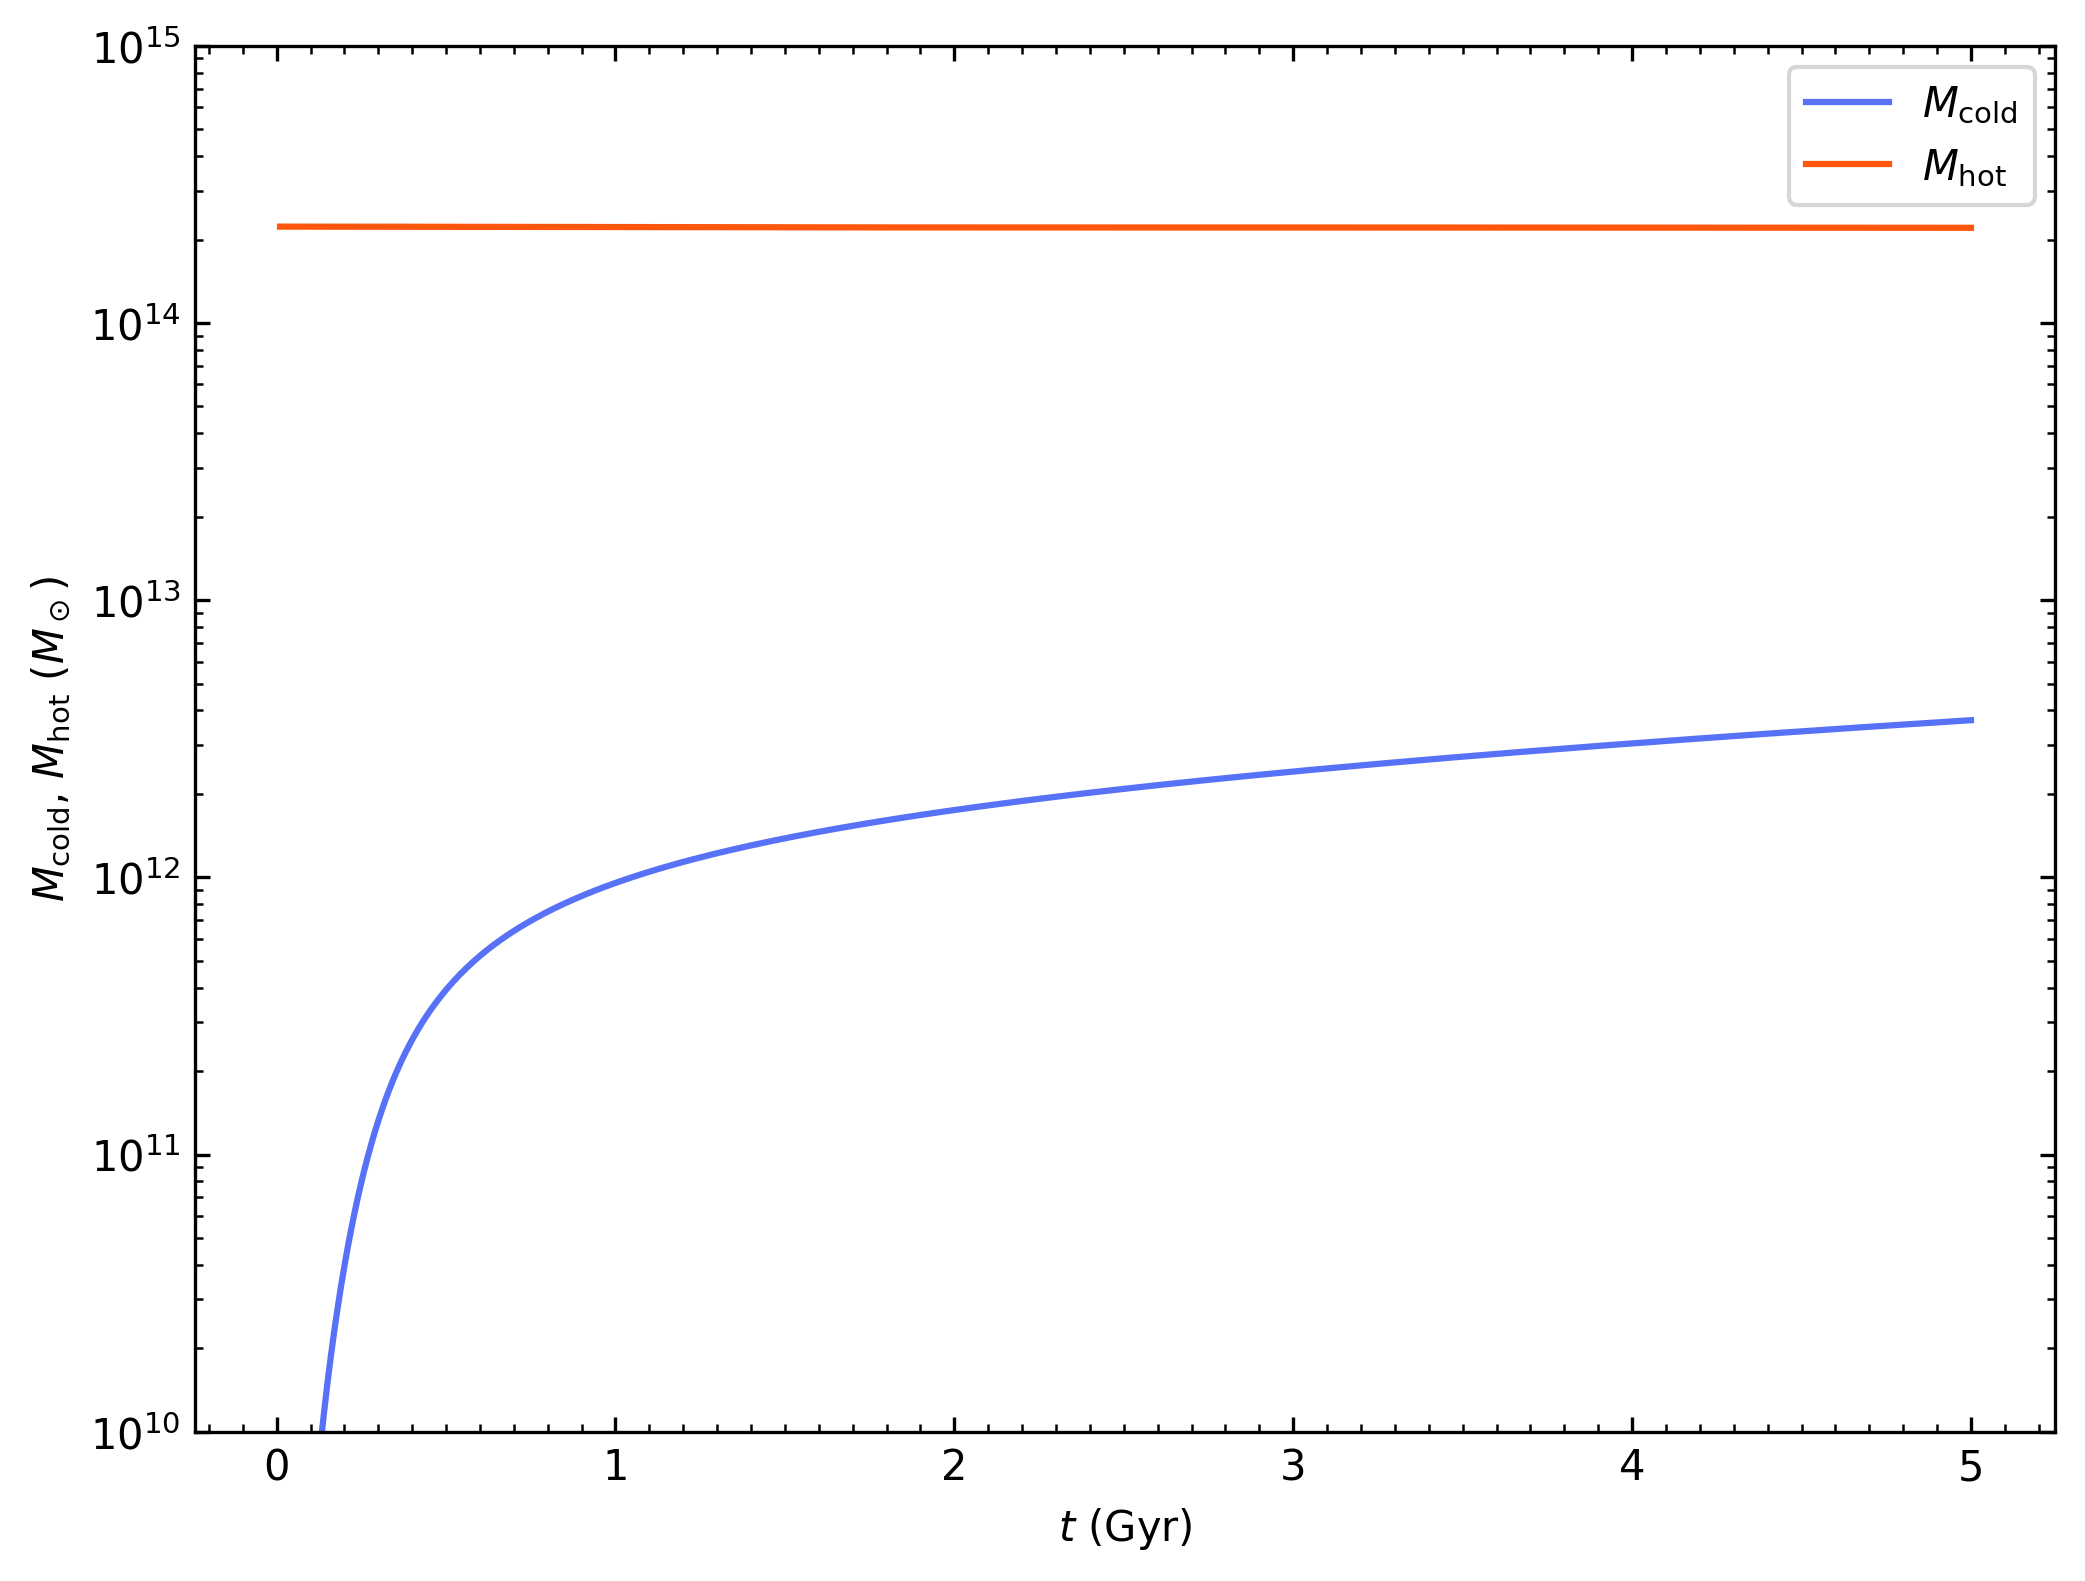

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import glob


m = np.loadtxt('mass_time.dat')
t = m[:,0]  # Gyr
mhot = m[:,1] # Msun
mcold = m[:,2] # Msun
Lx = m[:,3] # 10^45 Lsun
Lx500 = m[:,4] # 10^45 Lsun

fig, ax = plt.subplots(figsize=(8,6),dpi=300)
plt.plot(t, np.log10(Lx), label=r'$L_x (R_{vir})$', c="#5772f7",ls='-')
plt.plot(t, np.log10(Lx500), label=r'$L_x (<0.5R_{vir})$', c="#ff560e",ls='-')

# plt.xscale('log')
# plt.yscale('log')
plt.xlabel(r'$t$ (Gyr)')
plt.ylabel(r'$\log L_X$ ($10^{45} \rm{erg~s^{-1}}$)')
plt.ylim(-0.4,1.2)
# plt.xlim(-0.5,3.2)
plt.legend()
ax.tick_params(right='on',top='on', which='major',direction='in')
ax.tick_params(right='on',top='on', which='minor',direction='in')
# ax.xaxis.set_minor_locator(MultipleLocator(0.1))
# ax.yaxis.set_minor_locator(MultipleLocator(0.1))
plt.savefig('LX_L.pdf', format='pdf',dpi=300,bbox_inches='tight')

fig, ax = plt.subplots(figsize=(8,6),dpi=300)
plt.plot(t, mcold, label=r'$M_{\rm cold}$', c="#5772f7",ls='-')
plt.plot(t, mhot, label=r'$M_{\rm hot}$', c="#ff560e",ls='-')

# plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$t$ (Gyr)')
plt.ylabel(r'$M_{\rm cold}$, $M_{\rm hot}$ ($M_\odot$)')
plt.ylim(10**10, 10**15)
# plt.xlim(-0.5,3.2)
plt.legend()
ax.tick_params(right='on',top='on', which='major',direction='in')
ax.tick_params(right='on',top='on', which='minor',direction='in')
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
# ax.yaxis.set_minor_locator(MultipleLocator(0.1))
plt.savefig('mass_CH.pdf', format='pdf',dpi=300,bbox_inches='tight')

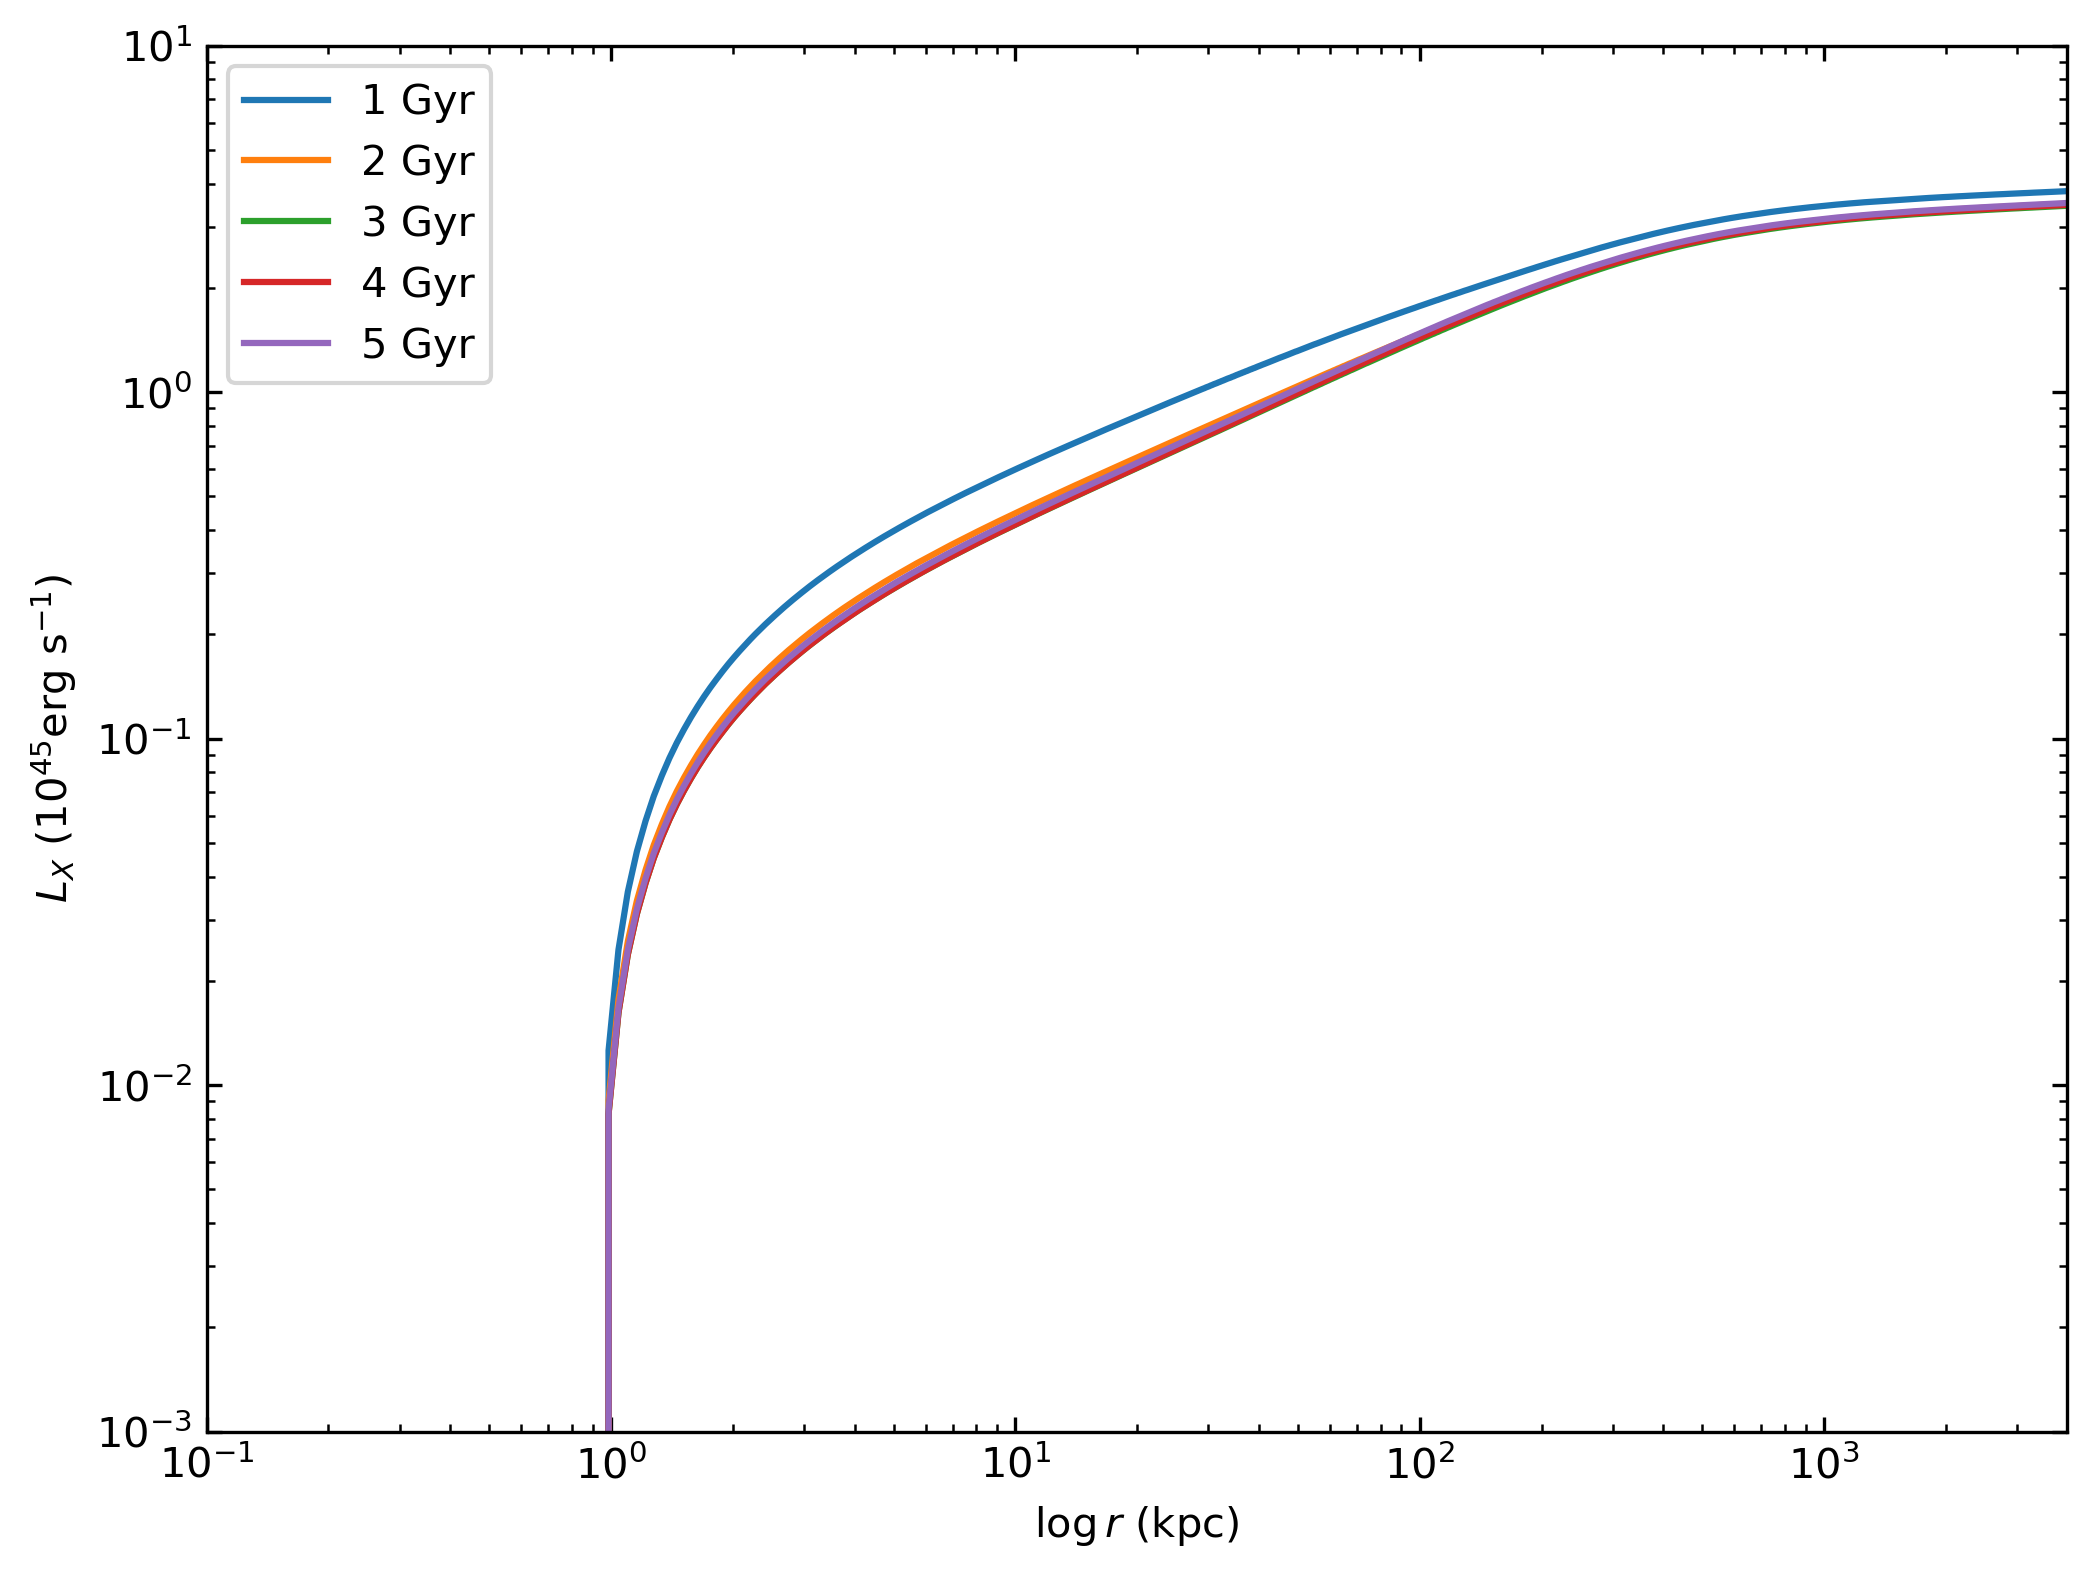

In [13]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import glob

files = sorted(glob.glob('lx*'))

fig, ax = plt.subplots(figsize=(8,6),dpi=300)
for i in range(len(files)):
    data = np.loadtxt(files[i]) 
    xb = data[:,0] # kpc
    lx = data[:,1]
    
    # plt.plot(xa, lx, label=f'{i+1} Gyr')
    plt.plot(xb, lx, label=f'{i+1} Gyr')


plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\log r$ (kpc)')
plt.ylabel(r'$L_X$ ($10^{45} \rm{erg~s^{-1}}$)')
plt.ylim(10**-3,10)
plt.xlim(10**-1,10**3.6)
plt.legend()
ax.tick_params(right='on',top='on', which='major',direction='in')
ax.tick_params(right='on',top='on', which='minor',direction='in')
plt.savefig('LX_profile.pdf', format='pdf',dpi=300,bbox_inches='tight')
# plt.text(0.1, 10**0, r'incorrect', color='r', alpha=0.5, fontsize=40)
# ax.xaxis.set_minor_locator(MultipleLocator(0.1))
# ax.yaxis.set_minor_locator(MultipleLocator(0.1))

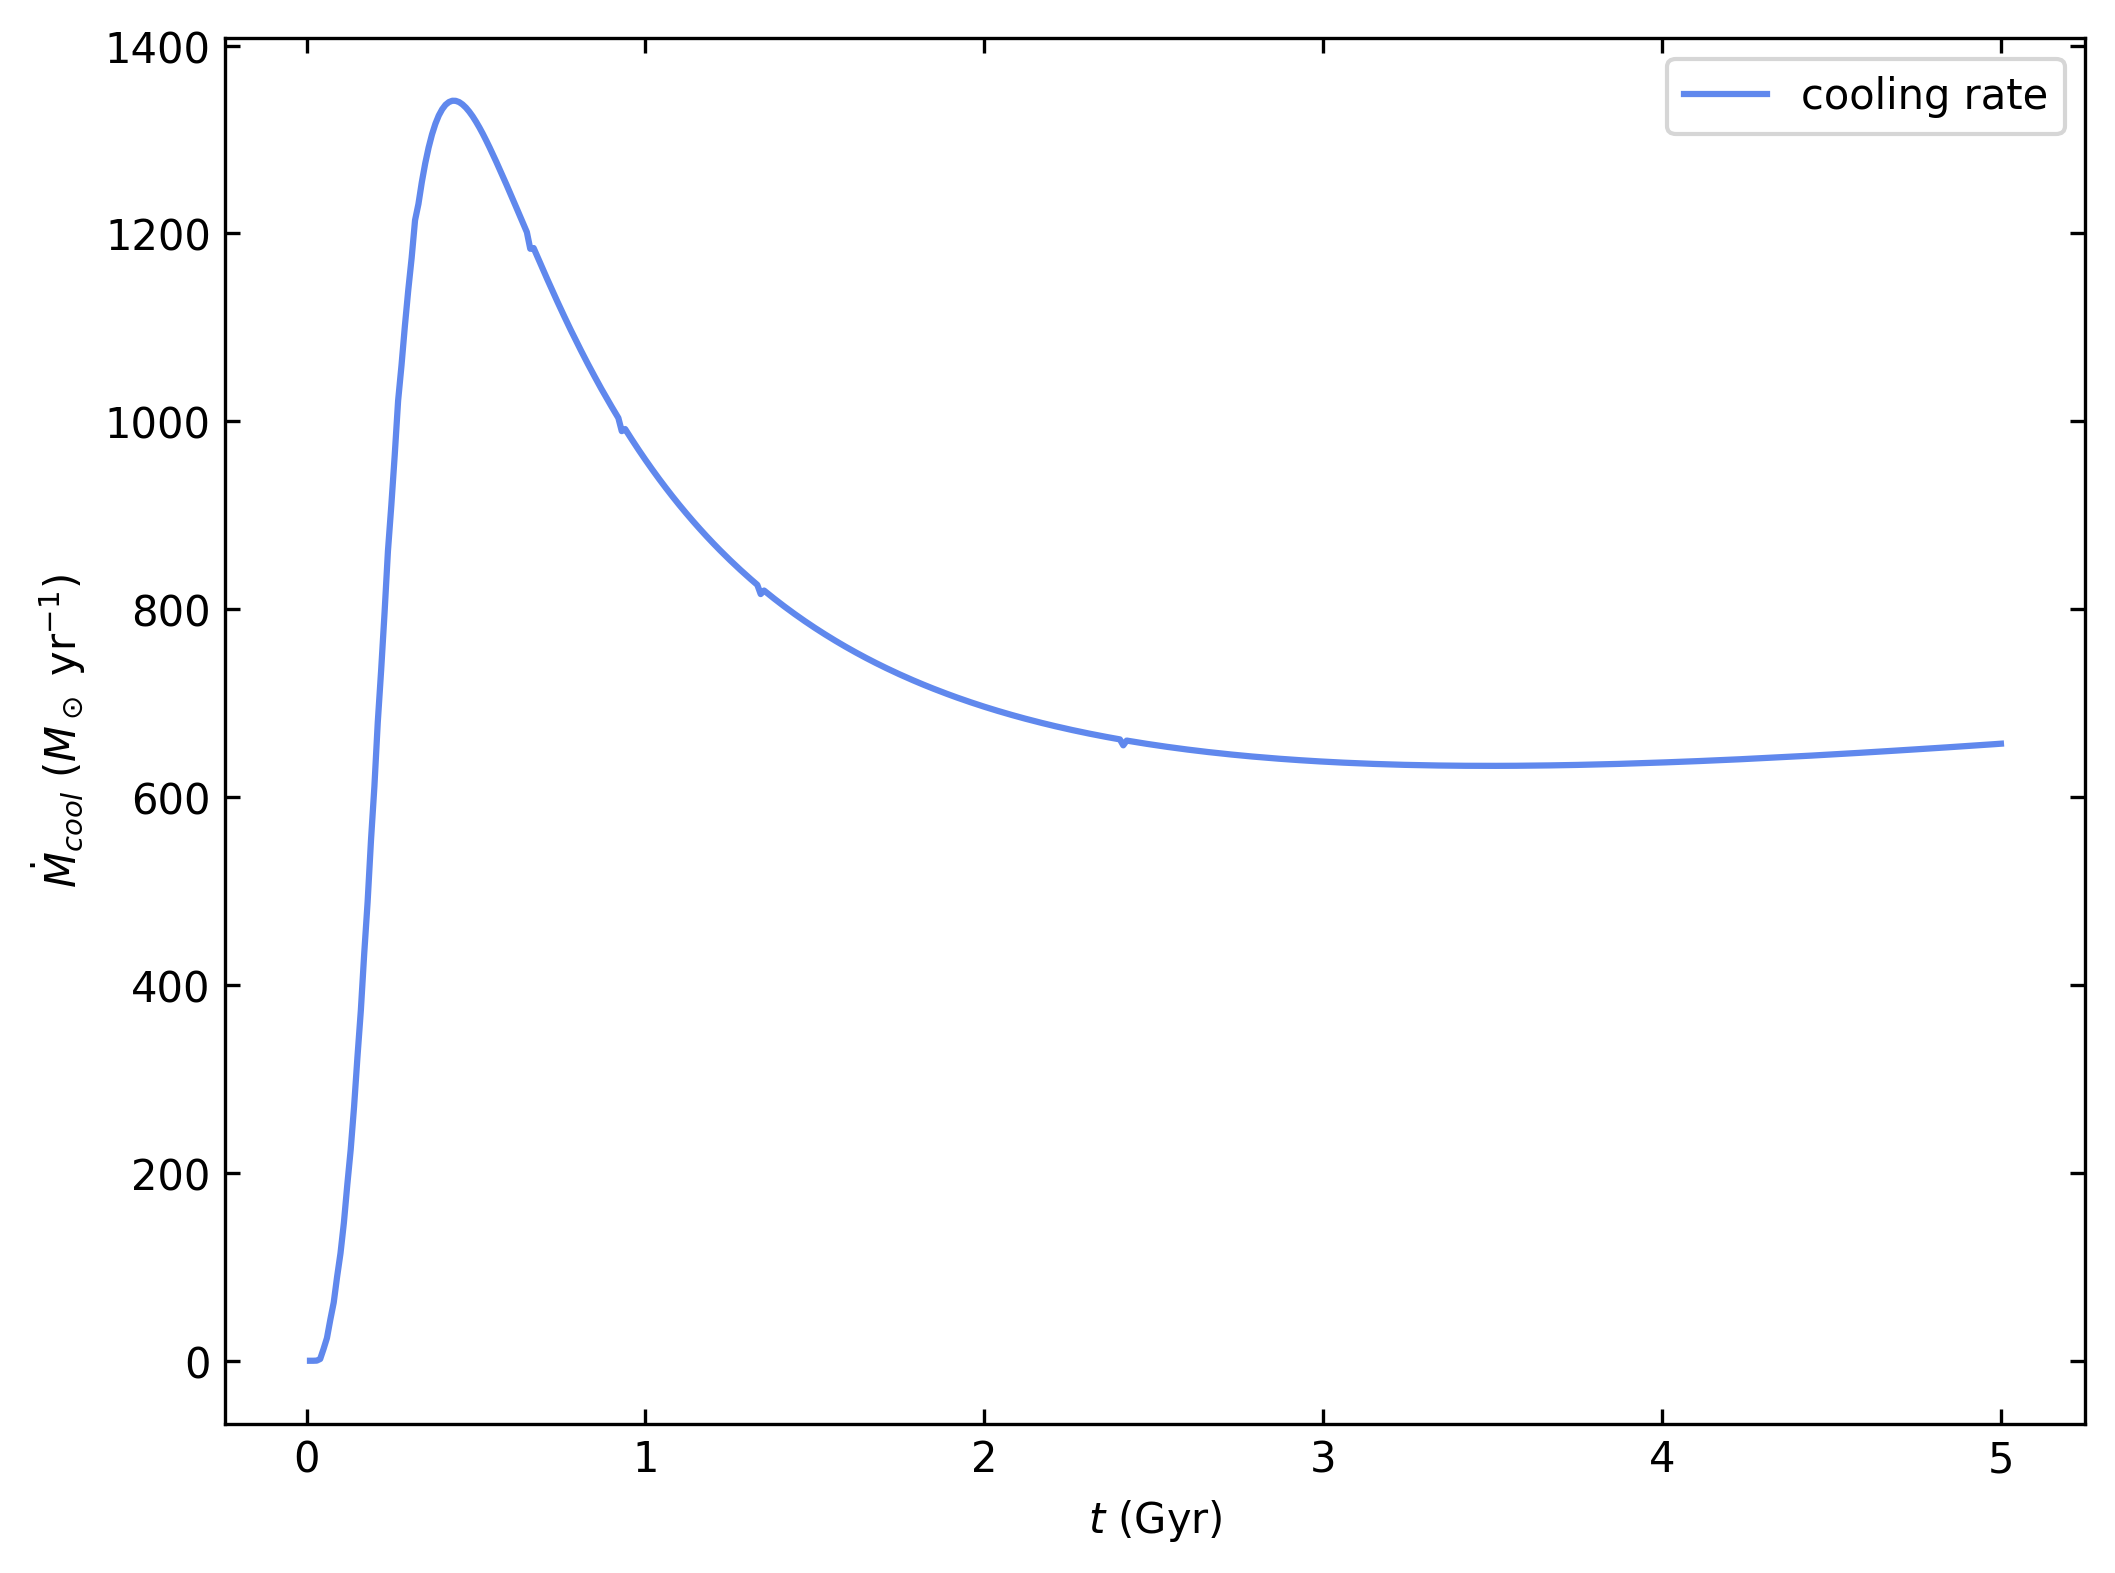

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import glob


mdot_cool = np.loadtxt('mdot_time.dat')
t = mdot_cool[:,0]  # Gyr
mdot = mdot_cool[:,1] # per msun * yr
kb = 1.380649e-16  # erg/K
mu = 0.61  # mean molecular weight
mp = 1.6726219e-24  # g
cmkpc=3.085**21

# files = sorted(glob.glob('clu00*'))
# lx = sorted(glob.glob('lx*'))

# fig, ax = plt.subplots(figsize=(8,6),dpi=300)
# for i in range(len(files)):
#     Stand_simu = np.loadtxt(files[i]) 
#     data = np.loadtxt(lx[i]) 
#     xb = data[:,0]
#     Lx = data[:,1]
#     tem = Stand_simu[:,4]
#     # xa = Stand_simu[:,0]
#     Mcool = 2/5 * mu * mp / (kb * tem) * Lx * 10**45 / (1.989e33) * (3.15e7) # cgs --> Msun/yr
#     plt.plot(xa,Mcool,label=f'{i+1} Gyr')
# plt.axhline(y=mdot_cool[-1,1], xmin=10**-3, xmax=10**3.6,label='cooling rate', c="#57c7f7",ls='-')
# plt.xscale('log')
# plt.xlim(10**-1,10**3.6)
# plt.ylim(0, 2700)
# plt.text(0.1, 2000, r'incorrect', color='r', alpha=0.5, fontsize=40)
# plt.legend()
# ax.tick_params(right='on',top='on', which='major',direction='in')
# ax.tick_params(right='on',top='on', which='minor',direction='in')
# ax.yaxis.set_minor_locator(MultipleLocator(100))
# # ax.xaxis.set_minor_locator(MultipleLocator(0.1))

fig, ax = plt.subplots(figsize=(8,6),dpi=300)
plt.plot(mdot_cool[:,0], mdot_cool[:,1], label='cooling rate', c="#6088ed",ls='-')

# plt.xscale('log')
# plt.yscale('log')
plt.xlabel(r'$t$ (Gyr)')
plt.ylabel(r'$\dot{M}_{cool}$ ($M_\odot$ yr$^{-1}$)')
# plt.ylim(0,2.5)
# plt.xlim(-0.5,3.2)
plt.legend()
ax.tick_params(right='on',top='on', which='major',direction='in')
ax.tick_params(right='on',top='on', which='minor',direction='in')
# ax.xaxis.set_minor_locator(MultipleLocator(0.1))
# ax.yaxis.set_minor_locator(MultipleLocator(0.1))
plt.savefig('cooling_rate.pdf', format='pdf',dpi=300,bbox_inches='tight')


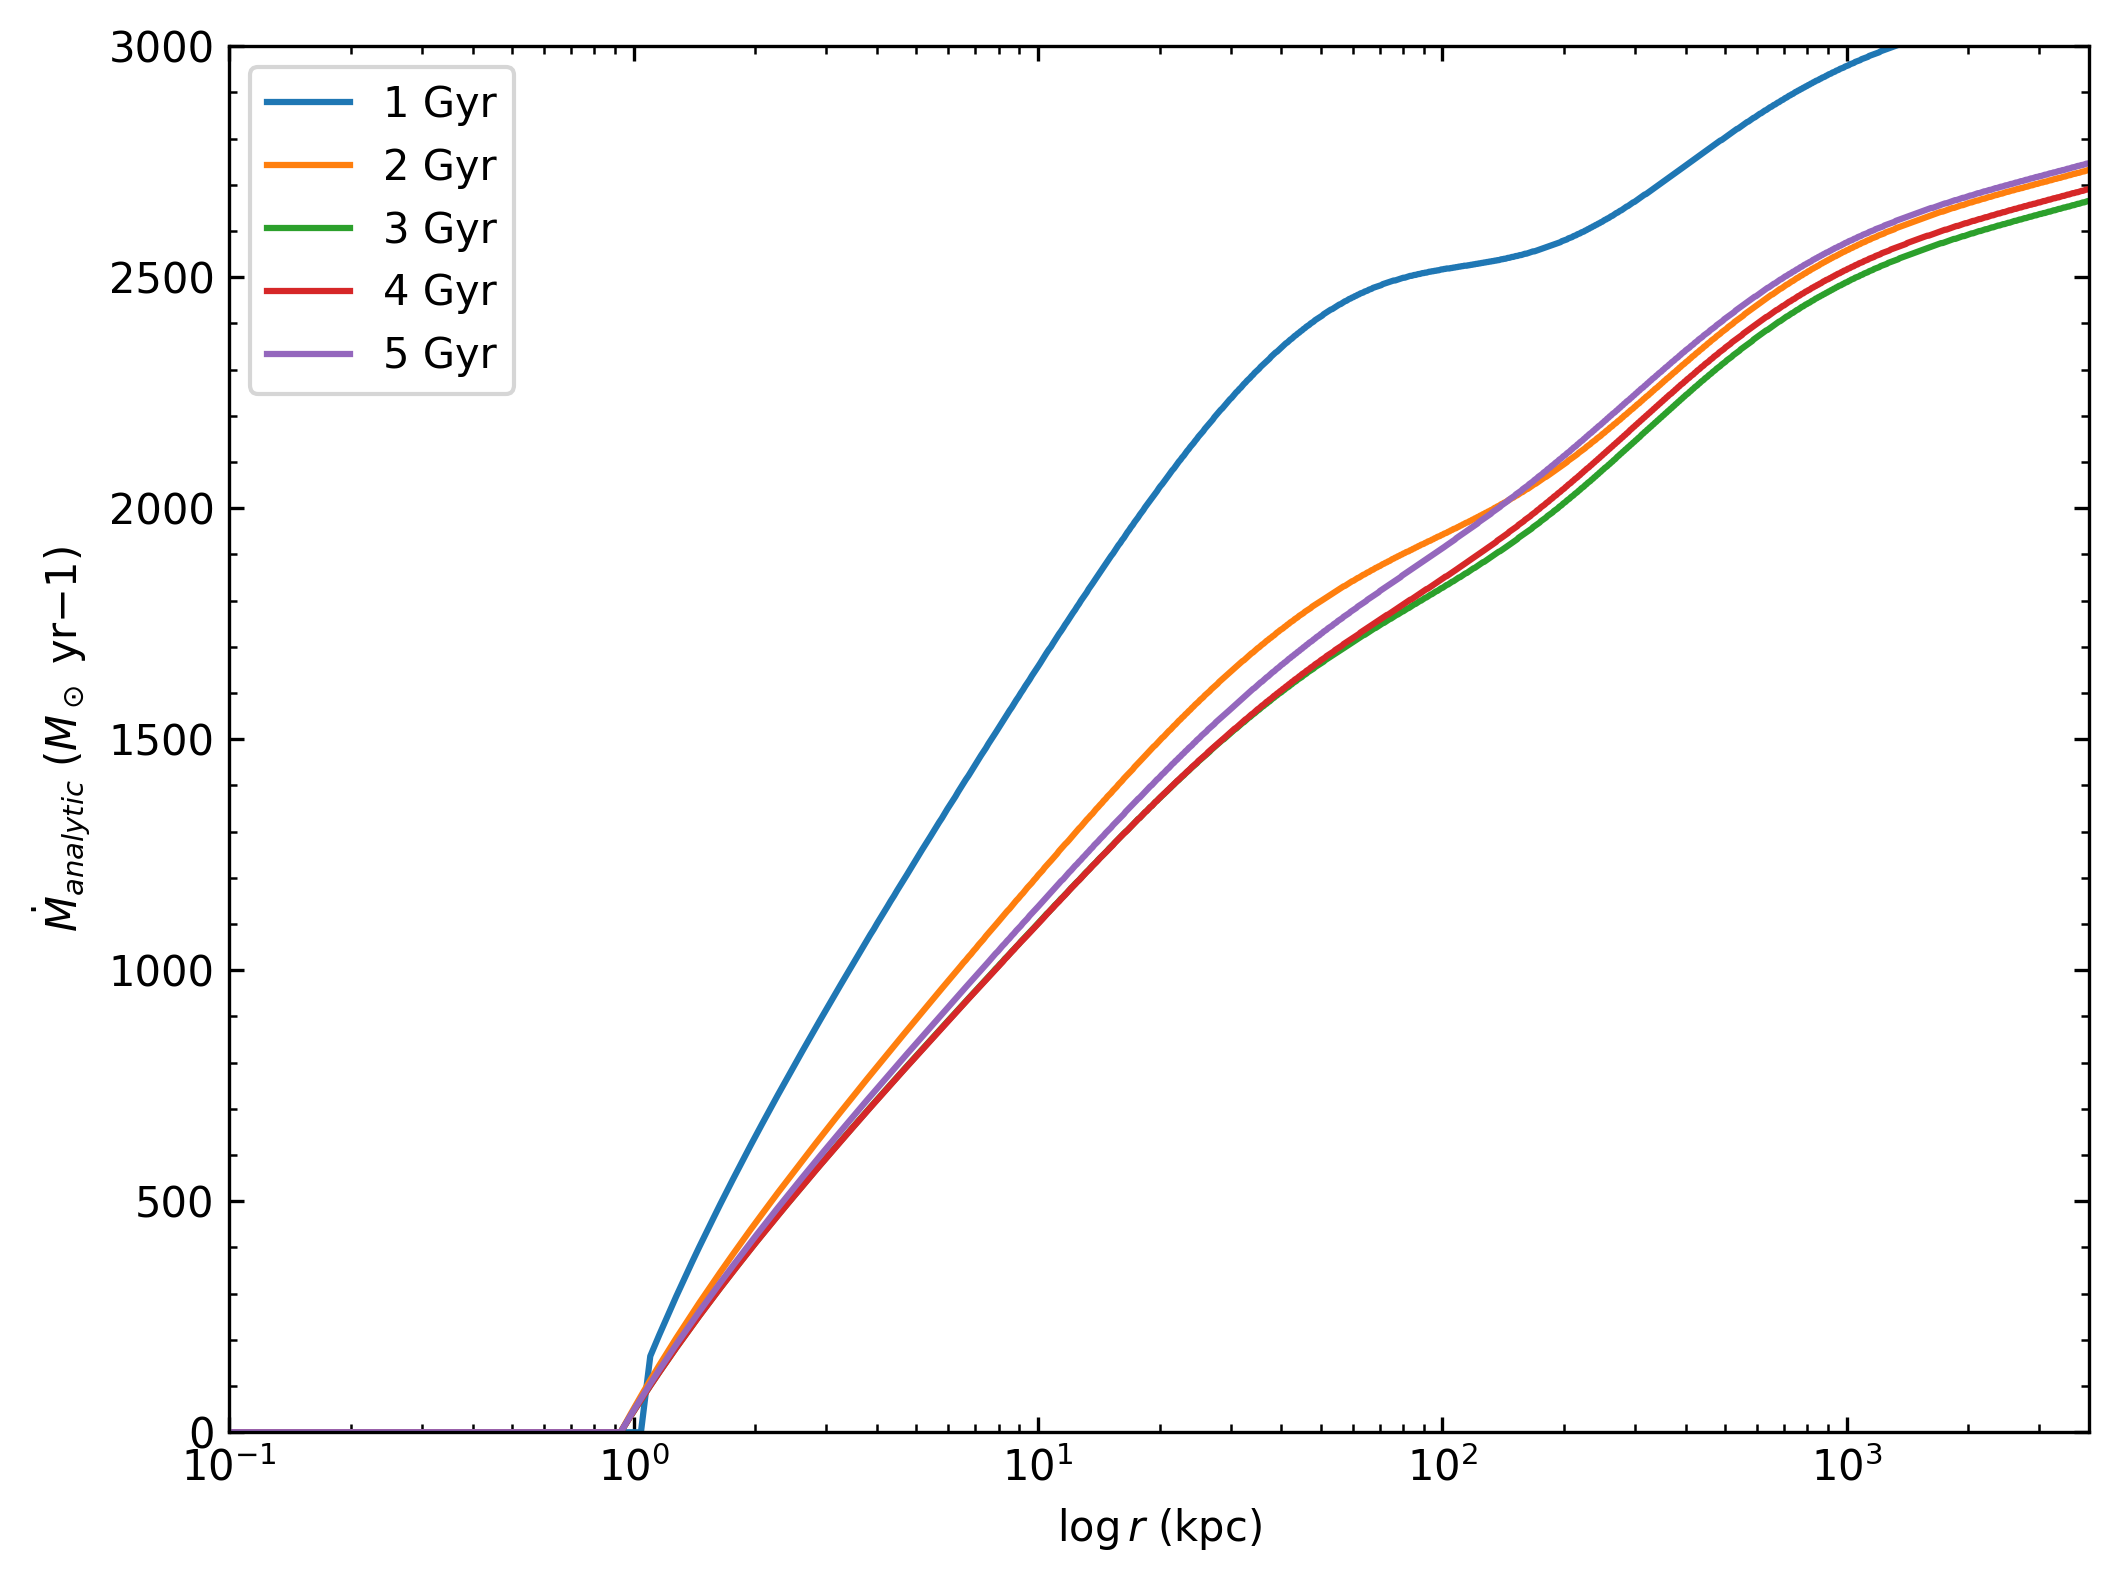

In [5]:
files = sorted(glob.glob('analy*'))

fig, ax = plt.subplots(figsize=(8,6),dpi=300)

for i in range(len(files)):
    data = np.loadtxt(files[i]) 
    xb = data[:,0]  # kpc
    mdot_analytic = data[:,3] # Msun/yr
    plt.plot(xb, mdot_analytic, label=f'{i+1} Gyr')
    
# plt.axhline(y=mdot_cool[-1,1], xmin=10**-3, xmax=10**3.6,label=r'True $\dot{M}_{\rm cool}$ of 5 Gyr by the simulation', c="#00047c",ls='-.')

plt.xscale('log')
# plt.yscale('log')
plt.xlabel(r'$\log r$ (kpc)')
plt.ylabel(r'$\dot{M}_{analytic}$ ($M_\odot$ yr${-1}$)')
plt.ylim(0,3000)
plt.xlim(10**-1,10**3.6)
# plt.text(0.1, 10**3, r'incorrect', color='r', alpha=0.5, fontsize=40)
plt.legend()
ax.tick_params(right='on',top='on', which='major',direction='in')
ax.tick_params(right='on',top='on', which='minor',direction='in')
ax.yaxis.set_minor_locator(MultipleLocator(100))
# ax.xaxis.set_minor_locator(MultipleLocator(0.1))
plt.savefig('cooling_rate_profile.pdf', format='pdf',dpi=300,bbox_inches='tight')

At r=3.32 kpc, the analytic cooling rate 661.10 Msun/yr exceeds the simulation cooling rate 656.87 Msun/yr, with the weight-averaged temperature 1.447, and the index i is 53.


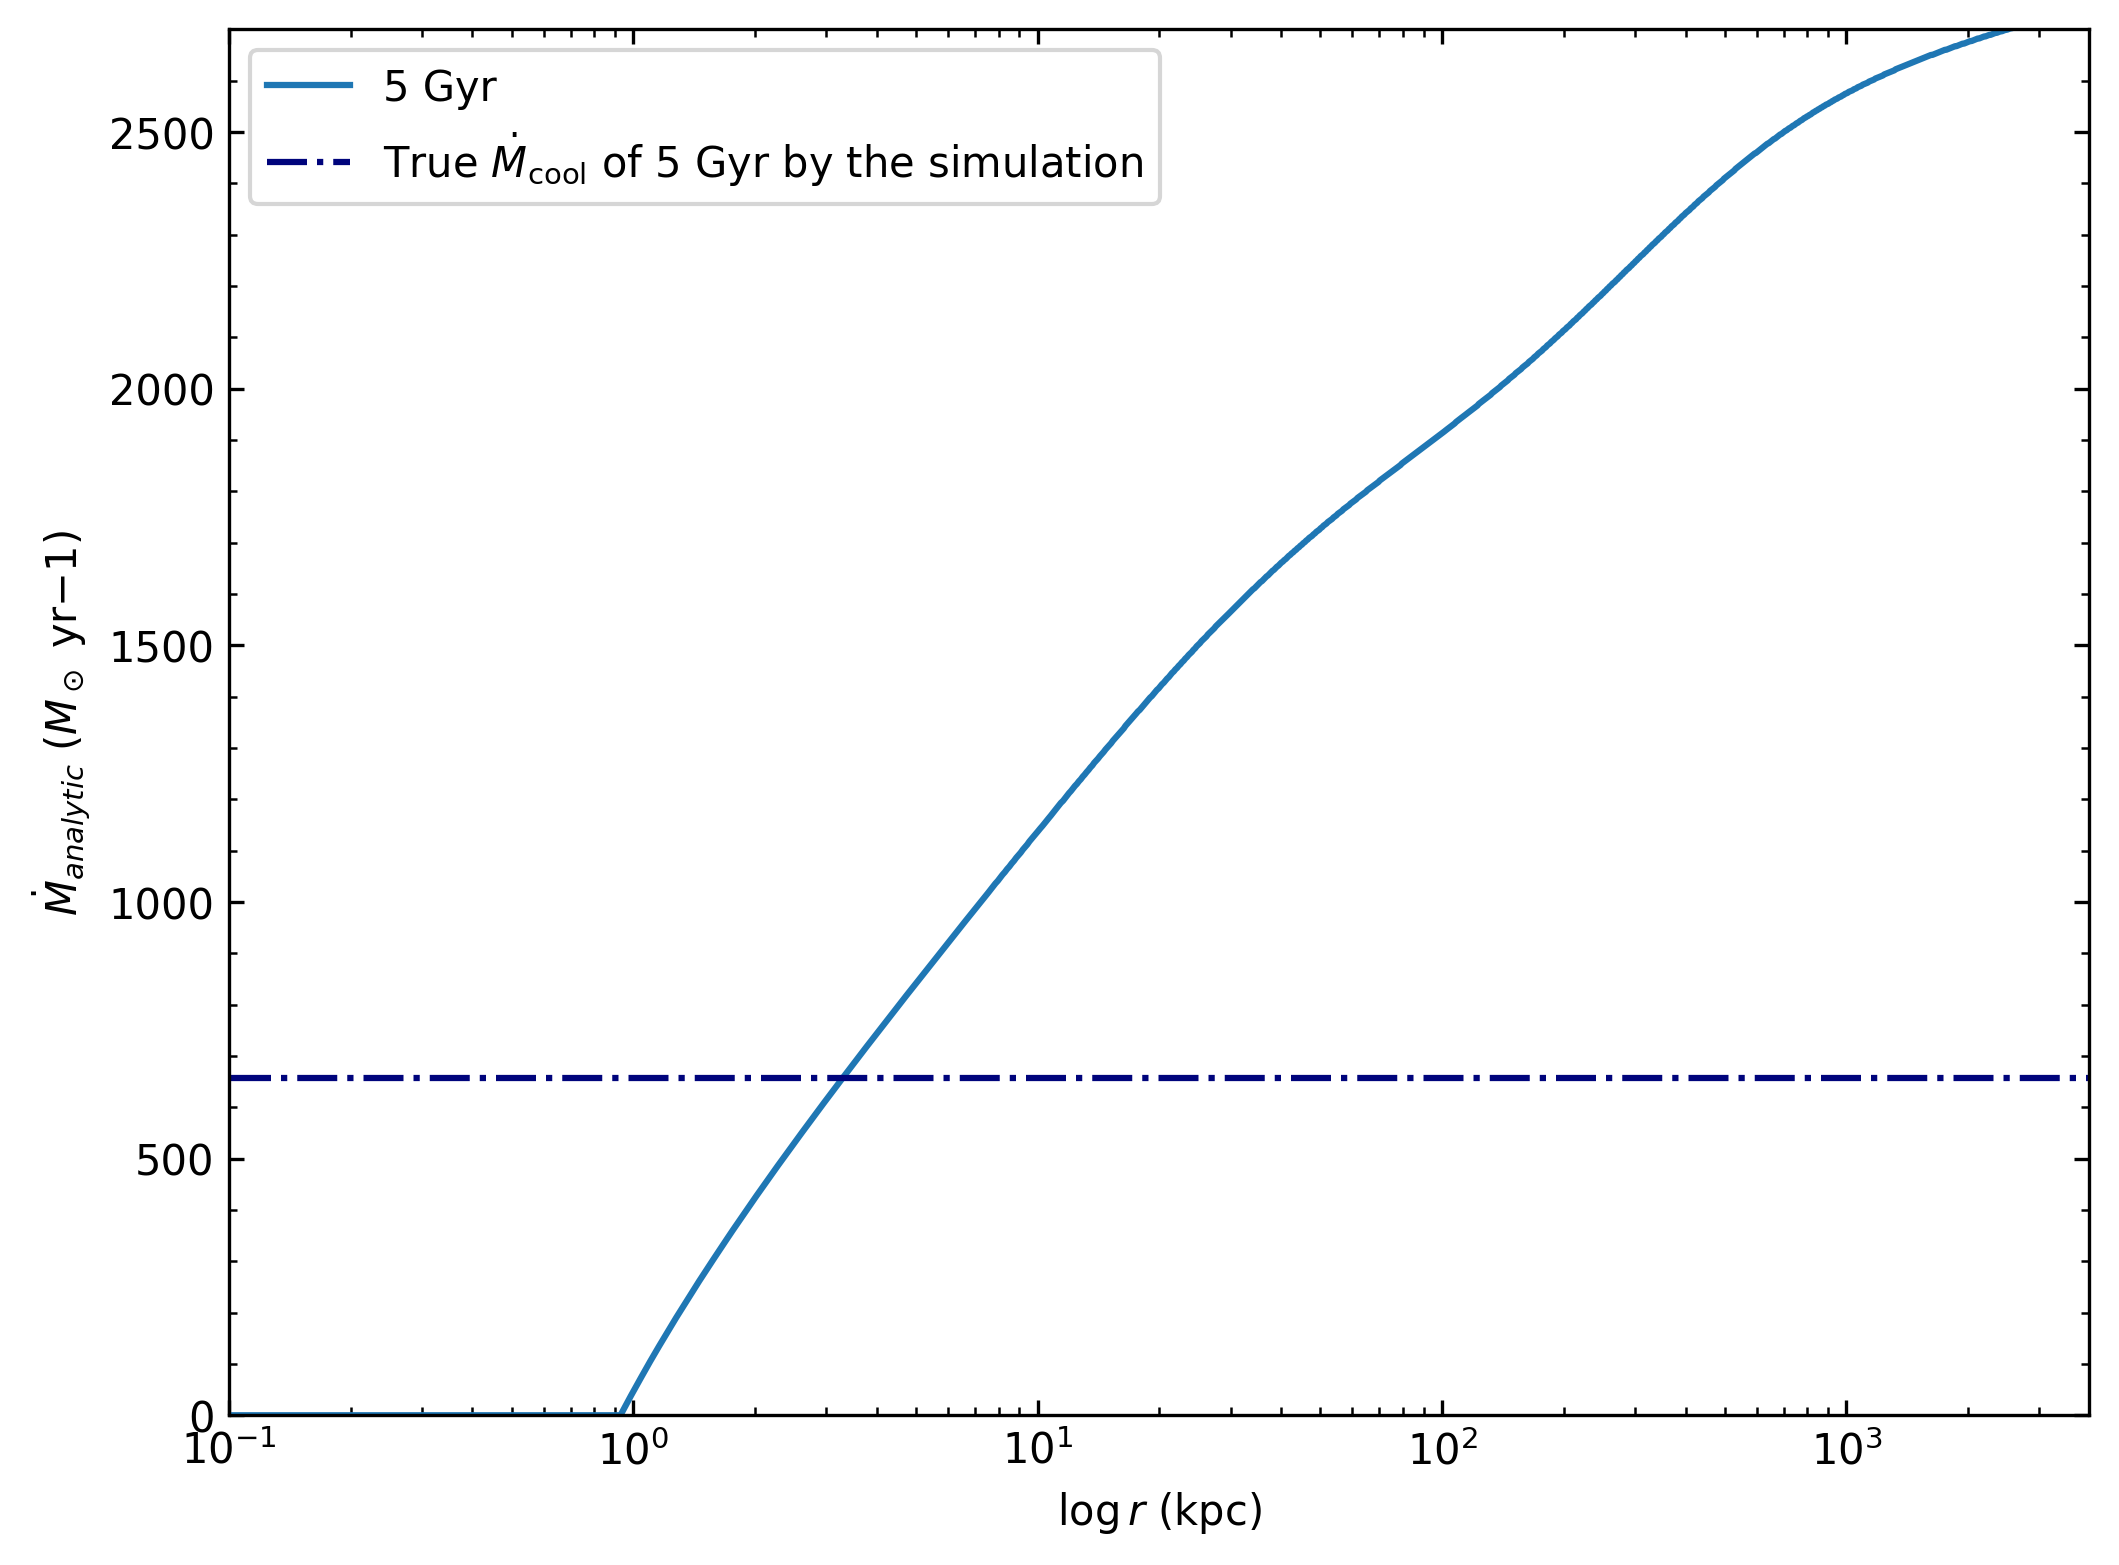

In [4]:
files = sorted(glob.glob('analy05'))

fig, ax = plt.subplots(figsize=(8,6),dpi=300)

for i in range(len(files)):
    data = np.loadtxt(files[i]) 
    tem = data[:,2] # K
    xb = data[:,0]  # kpc
    
    mdot_analytic = data[:,3] # Msun/yr
    plt.plot(xb, mdot_analytic, label=f'5 Gyr')
    
plt.axhline(y=mdot_cool[-1,1], xmin=10**-3, xmax=10**3.6,label=r'True $\dot{M}_{\rm cool}$ of 5 Gyr by the simulation', c="#00047c",ls='-.')

plt.xscale('log')
# plt.yscale('log')
plt.xlabel(r'$\log r$ (kpc)')
plt.ylabel(r'$\dot{M}_{analytic}$ ($M_\odot$ yr${-1}$)')
plt.ylim(0,2700)
plt.xlim(10**-1,10**3.6)
# plt.text(0.1, 10**3, r'incorrect', color='r', alpha=0.5, fontsize=40)
plt.legend()
ax.tick_params(right='on',top='on', which='major',direction='in')
ax.tick_params(right='on',top='on', which='minor',direction='in')
ax.yaxis.set_minor_locator(MultipleLocator(100))
# ax.xaxis.set_minor_locator(MultipleLocator(0.1))
plt.savefig('cooling_rate_5.pdf', format='pdf',dpi=300,bbox_inches='tight')

for i in range(len(xb)):
    if mdot_analytic[i] > mdot_cool[-1,1]:
        print(f'At r={xb[i]:.2f} kpc, the analytic cooling rate {mdot_analytic[i]:.2f} Msun/yr exceeds the simulation cooling rate {mdot_cool[-1,1]:.2f} Msun/yr, with the weight-averaged temperature {tem[i]/10**7}, and the index i is {i}.')
        break


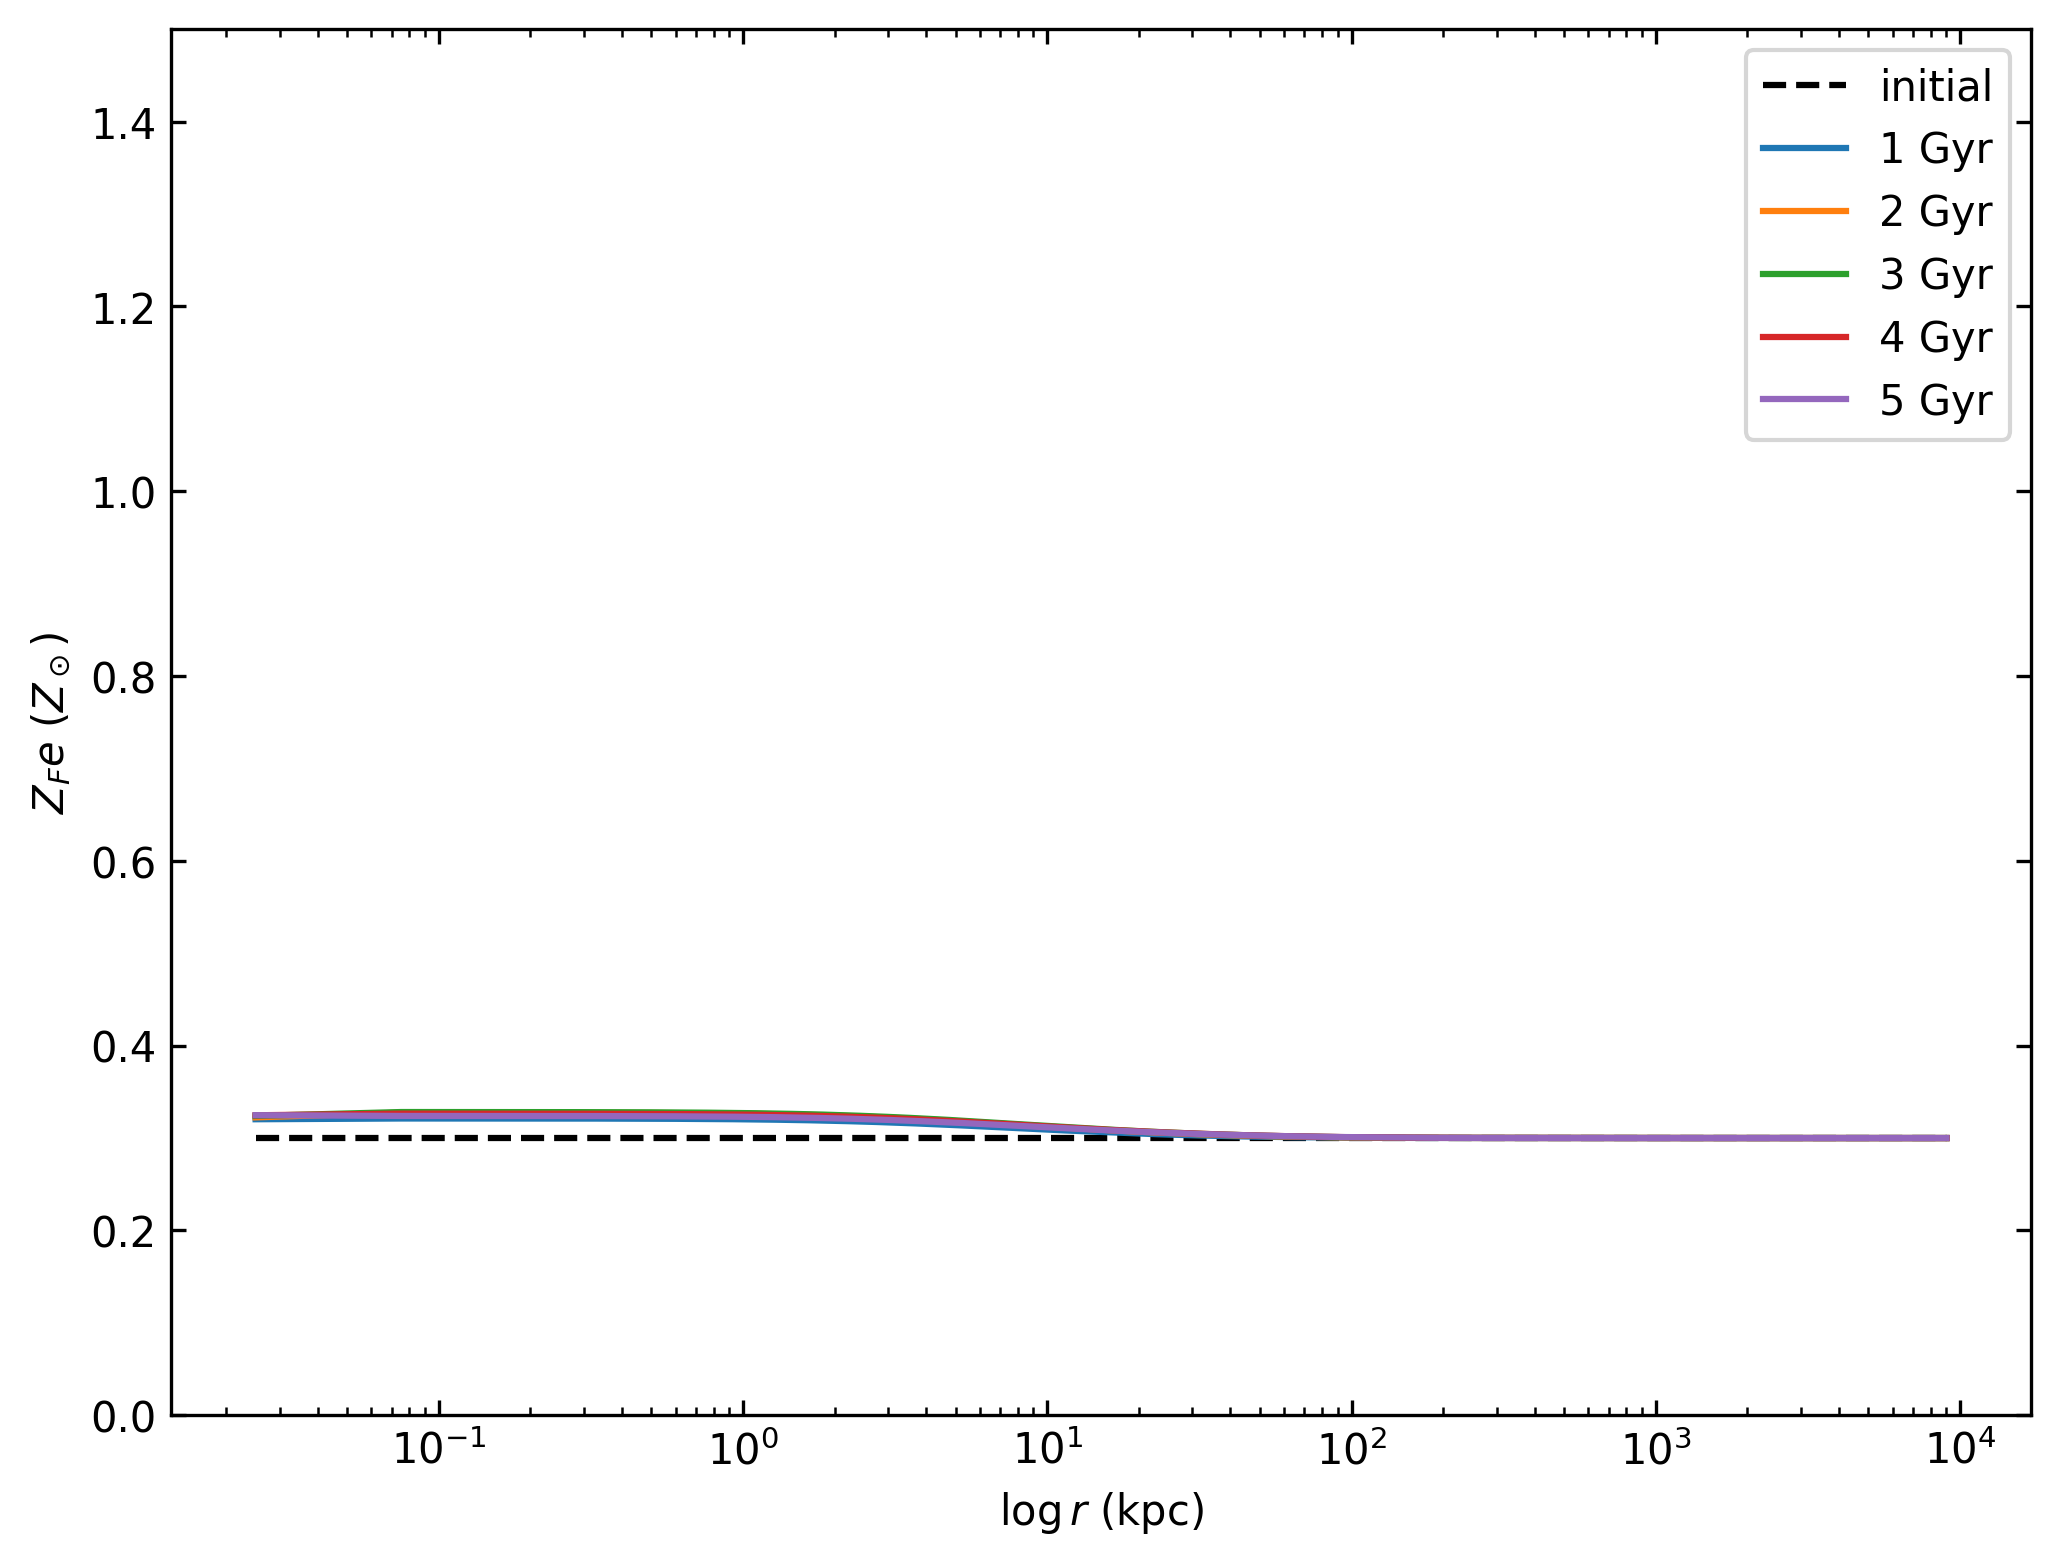

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import glob

files = sorted(glob.glob('abu0*'))
initb = np.loadtxt('abundinit.dat')
xb = initb[:,0]  # kpc
ZFe = initb[:,2]

fig, ax = plt.subplots(figsize=(8,6),dpi=300)
plt.plot(xb, ZFe, label='initial', c='k',ls='--')

for i in range(len(files)):
    data = np.loadtxt(files[i]) 
    xb = data[:,0]  # kpc
    rho_Fe = data[:,1]
    ZFe = data[:,2]
    
    plt.plot(xb, ZFe, label=f'{i+1} Gyr')
plt.xscale('log')
# plt.yscale('log')
plt.xlabel(r'$\log r$ (kpc)')
plt.ylabel(r'$Z_Fe$ ($Z_\odot$)')
plt.ylim(0,1.5)
# plt.xlim(-0.5,3.2)
plt.legend()
ax.tick_params(right='on',top='on', which='major',direction='in')
ax.tick_params(right='on',top='on', which='minor',direction='in')
plt.savefig('abundance_R.pdf', format='pdf',dpi=300,bbox_inches='tight')